In [1]:
import torch
print(torch.cuda.is_available())


True


In [2]:
!pip install transformers
!pip install pillow


In [3]:
from transformers import VisionEncoderDecoderModel, ViTImageProcessor, AutoTokenizer
import torch
from PIL import Image
from google.colab import files


In [4]:
model_name = "nlpconnect/vit-gpt2-image-captioning"

model = VisionEncoderDecoderModel.from_pretrained(model_name)
processor = ViTImageProcessor.from_pretrained(model_name)
tokenizer = AutoTokenizer.from_pretrained(model_name)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/982M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/445 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie decoder.transformer.wte.weight to decoder.lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
VisionEncoderDecoderModel LOAD REPORT from: nlpconnect/vit-gpt2-image-captioning
Key                                                       | Status     |  | 
----------------------------------------------------------+------------+--+-
decoder.transformer.h.{0...11}.crossattention.bias        | UNEXPECTED |  | 
decoder.transformer.h.{0...11}.crossattention.masked_bias | UNEXPECTED |  | 
decoder.transformer.h.{0...11}.attn.bias                  | UNEXPECTED |  | 
decoder.transformer.h.{0...11}.attn.masked_bias           | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

preprocessor_config.json:   0%|          | 0.00/228 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/241 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/120 [00:00<?, ?B/s]

VisionEncoderDecoderModel(
  (encoder): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (inte

In [5]:
uploaded = files.upload()


Saving Screenshot 2026-02-19 173145.png to Screenshot 2026-02-19 173145.png


In [7]:
image = Image.open(list(uploaded.keys())
[0]).convert("RGB")

pixel_values = processor(images=image, return_tensors="pt").pixel_values
pixel_values = pixel_values.to(device)

output_ids = model.generate(pixel_values, max_length=20, num_beams=4)
caption = tokenizer.decode(output_ids[0], skip_special_tokens=True)

print("Basic Caption:")
print(caption)


The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
We strongly recommend passing in an `attention_mask` since your input_ids may be padded. See https://huggingface.co/docs/transformers/troubleshooting#incorrect-output-when-padding-tokens-arent-masked.
You may ignore this warning if your `pad_token_id` (50256) is identical to the `bos_token_id` (50256), `eos_token_id` (50256), or the `sep_token_id` (None), and your input is not padded.


Basic Caption:
a large building with a clock on top of it 


In [8]:
import random

def catchy_caption(base_caption):

    styles = [
        f"{base_caption.capitalize()} — but make it iconic ✨",
        f"Serving views and vibes 😎",
        f"Proof that moments like this exist 🌍",
        f"Main character energy right here 🎬",
        f"{base_caption.capitalize()}, but make it aesthetic 📸",
        f"Caught in a frame, living in a vibe 💫",
        f"Where history meets the sky ⏳",
        f"Just out here creating memories 🧡"
    ]

    return random.choice(styles)


def smart_hashtags(base_caption):
    keywords = base_caption.split()
    tags = ["#" + word for word in keywords if len(word) > 3]
    tags += ["#InstaVibes", "#ExploreMore", "#TravelGram"]
    return " ".join(tags[:6])


print("\n✨ Catchy Caption:")
print(catchy_caption(caption))

print("\n🔥 Hashtags:")
print(smart_hashtags(caption))



✨ Catchy Caption:
Main character energy right here 🎬

🔥 Hashtags:
#large #building #with #clock #InstaVibes #ExploreMore


In [9]:
def trendy_caption(base_caption):
    return base_caption + " ✨ Timeless vibes!"

def emoji_caption(base_caption):
    return base_caption + " 🏛️⏰"

def aesthetic_caption(base_caption):
    return "Lost in the beauty of " + base_caption

def hashtag_generator(base_caption):
    words = base_caption.split()
    hashtags = ["#" + word for word in words[:3]]
    return " ".join(hashtags)

print("\nTrendy Caption:")
print(trendy_caption(caption))

print("\nEmoji Caption:")
print(emoji_caption(caption))

print("\nAesthetic Caption:")
print(aesthetic_caption(caption))

print("\nHashtags:")
print(hashtag_generator(caption))



Trendy Caption:
a large building with a clock on top of it  ✨ Timeless vibes!

Emoji Caption:
a large building with a clock on top of it  🏛️⏰

Aesthetic Caption:
Lost in the beauty of a large building with a clock on top of it 

Hashtags:
#a #large #building


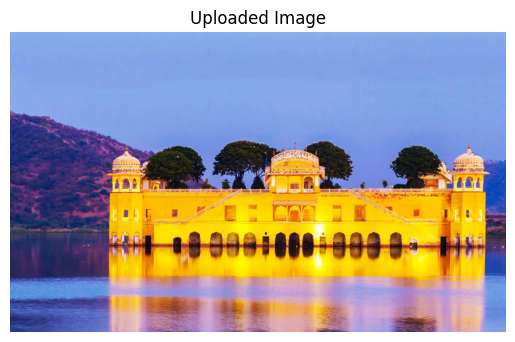

In [10]:
import matplotlib.pyplot as plt

plt.imshow(image)
plt.axis("off")
plt.title("Uploaded Image")
plt.show()


In [11]:
def mood_caption(base_caption, mood):

    if mood == "Travel":
        return f"Wander often, wonder always 🌍 | {base_caption}"

    elif mood == "Aesthetic":
        return f"Soft lights & timeless sights ✨ | {base_caption}"

    elif mood == "Savage":
        return f"Built different. Built iconic 😎 | {base_caption}"

    elif mood == "Motivation":
        return f"Every moment counts ⏳ | {base_caption}"

    else:
        return base_caption


mood = "Travel"   # Change mood here

print("\nMood Based Caption:")
print(mood_caption(caption, mood))



Mood Based Caption:
Wander often, wonder always 🌍 | a large building with a clock on top of it 


In [12]:
mood = "Aesthetic"


In [13]:
print("="*50)
print("✨ PixCap - AI Caption Generator ✨")
print("="*50)

print("\n📌 Basic:")
print(caption)

print("\n🔥 Catchy:")
print(catchy_caption(caption))

print("\n🎭 Mood Style:")
print(mood_caption(caption, "Aesthetic"))

print("\n#️⃣ Hashtags:")
print(smart_hashtags(caption))

print("="*50)


✨ PixCap - AI Caption Generator ✨

📌 Basic:
a large building with a clock on top of it 

🔥 Catchy:
Serving views and vibes 😎

🎭 Mood Style:
Soft lights & timeless sights ✨ | a large building with a clock on top of it 

#️⃣ Hashtags:
#large #building #with #clock #InstaVibes #ExploreMore
